In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from astro_peek.identifier.cca import CCA_Score
from astro_peek.nets.encoder_base import Encoder
from astro_peek.trainer.transforms import patch_cifar10
import torch


/home/ssalhi/model_training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
'''Load the two ENCODER_FEATURES models and pass the training set into both of them. This will map the training set x to the latent space'''

models_path = '/home/ssalhi/scratch/crl/experiments/cifar10/models/encoder_features/'

encoder_1_path = models_path + 'seed_37_latentdim_64.pt'
encoder_2_path = models_path + 'seed_38_latentdim_64.pt'

print("Loading the models for different random seeds ")
load_encoder_1 = torch.load(encoder_1_path, map_location="cpu")
load_encoder_2 = torch.load(encoder_2_path, map_location="cpu")

encoder_1 = Encoder(load_encoder_1["model_cfg"])
encoder_2 = Encoder(load_encoder_2["model_cfg"])

# load the data
images = torch.load("/home/ssalhi/scratch/cifar10_data/train_images.pt", weights_only=False)
images = torch.as_tensor(images).squeeze().contiguous()
N = images.shape[0]

# patch it 
x, y = patch_cifar10(images)

# flatten the images 
x = x.reshape(N, -1)
y = y.reshape(N, -1)
print(x.shape)

latents_model_1 = encoder_1(x)
latents_model_2 = encoder_2(x)

print(latents_model_1.shape, latents_model_2.shape)

Loading the models for different random seeds 
torch.Size([50000, 768])
torch.Size([50000, 64]) torch.Size([50000, 64])


In [3]:
'''Make sure the latents have the right shape. Concatenate them into one array so that model_list has shape (2, nsamples, nlatents)'''

model_latent_list = torch.stack([latents_model_1, latents_model_2], axis=0)
print(model_latent_list.shape)

torch.Size([2, 50000, 64])


(64,)


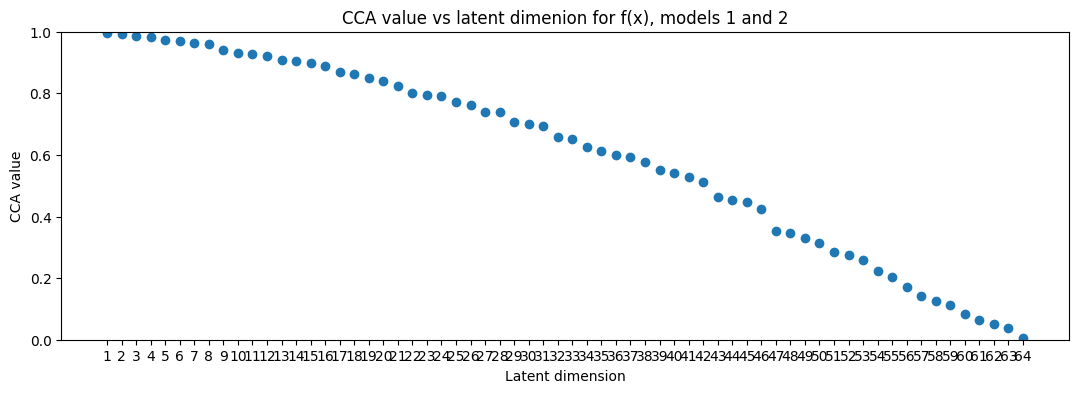

In [4]:
'''Create a CCA_Score object with the model_list, calculate the pairwise CCA values, and plot them.'''

CCA = CCA_Score(model_list=model_latent_list.detach().numpy())
corrs = CCA.compute_one_pair_cca()

print(corrs.shape)

# plot the CCA scores as a function of the latents 
CCA.plot_cca_v_latent(corrs)

## Testing comparison between more than 2 models

In [5]:
from tqdm import tqdm 

def load_model(paths):
    model_list = []
    for path in tqdm(paths): 
        model_data = torch.load(path, map_location = "cpu")
        cfg = model_data['model_cfg']
        model = Encoder(cfg)
        model_list.append(model)
    return model_list

In [6]:
from glob import glob
from natsort import natsorted

model_path = "/home/ssalhi/scratch/crl/experiments/cifar10/models/"
encoders_features_dir = "encoder_features/"
encoders_labels_dir = "encoder_labels/"
pattern = "*.pt"

encoder_x_paths = natsorted(glob(model_path + encoders_features_dir + pattern))  
encoder_y_paths = natsorted(glob(model_path + encoders_labels_dir + pattern))

print("Loading the models for different random seeds ")
encoder_x_list = load_model(encoder_x_paths)
encoder_y_list = load_model(encoder_y_paths)

Loading the models for different random seeds 


100%|██████████| 5/5 [00:00<00:00, 360.05it/s]


In [7]:
# make the list of models 
model_list_x = []
model_list_y = []
for i in range(len(encoder_x_list)):
    latents_x = encoder_x_list[i](x)
    latents_y = encoder_y_list[i](y)
    
    model_list_x.append(latents_x)
    model_list_y.append(latents_y)
    
model_list_x = torch.stack(model_list_x, axis=0)
model_list_y = torch.stack(model_list_y, axis=0)

print(model_list_x.shape, model_list_y.shape)

torch.Size([5, 50000, 64]) torch.Size([5, 50000, 64])


In [8]:
# calculate all pairwise CCA scores
CCA_multi_x = CCA_Score(model_list=model_list_x.detach().numpy())
CCA_multi_y = CCA_Score(model_list=model_list_y.detach().numpy())

mcorrs_x = CCA_multi_x.compute_all_pairwise_cca()
mcorrs_y = CCA_multi_y.compute_all_pairwise_cca()

print(mcorrs_x.shape, mcorrs_y.shape)

(5, 5, 64) (5, 5, 64)


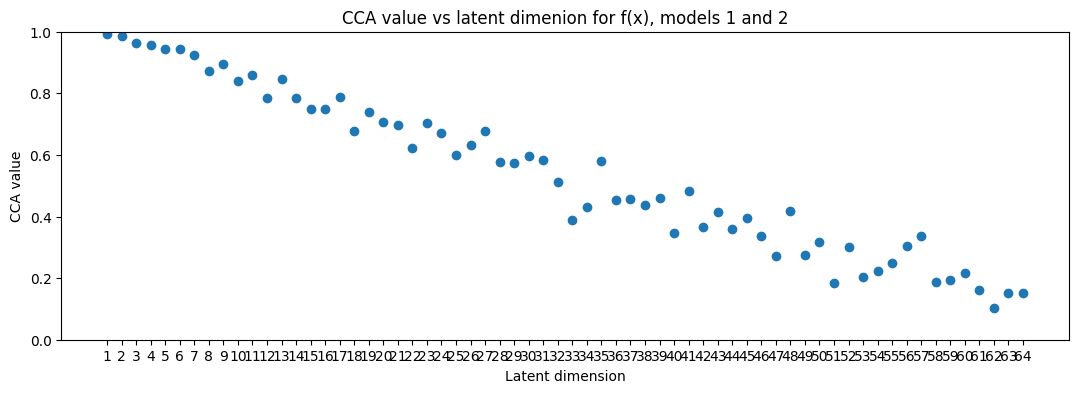

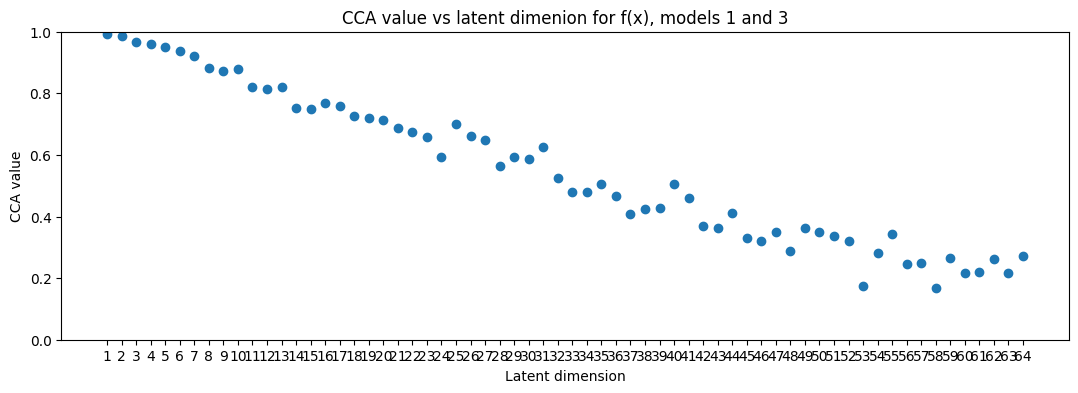

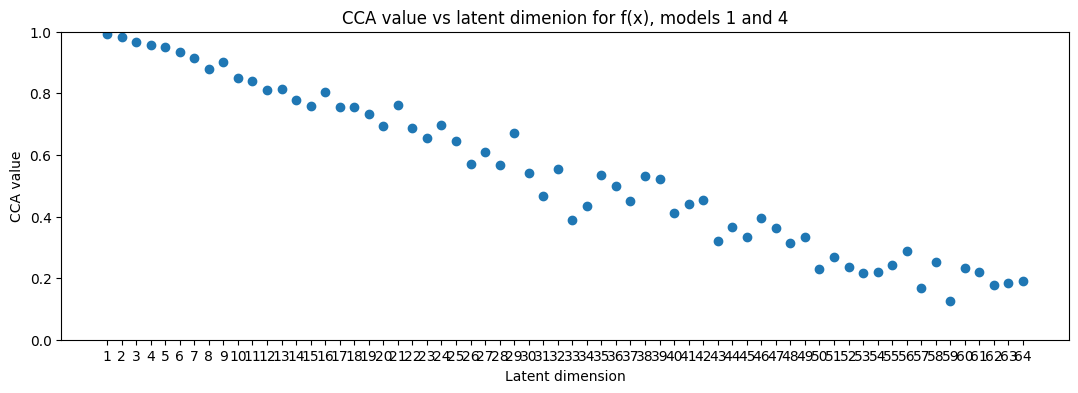

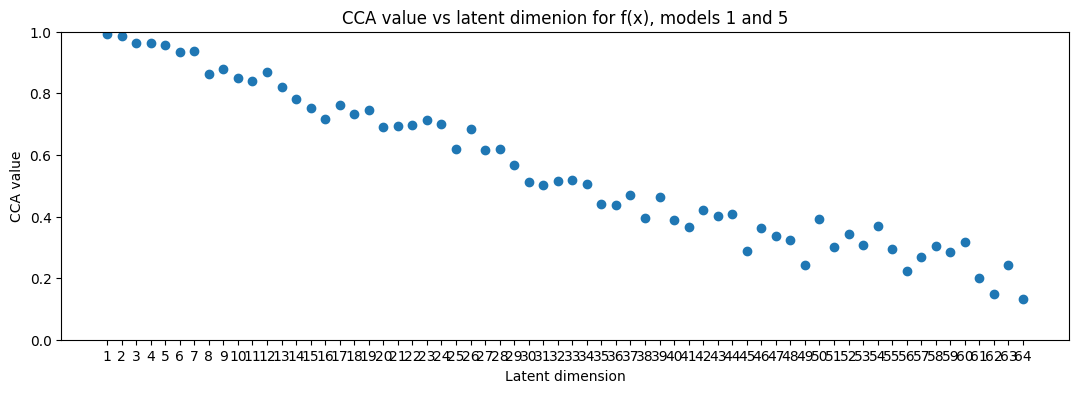

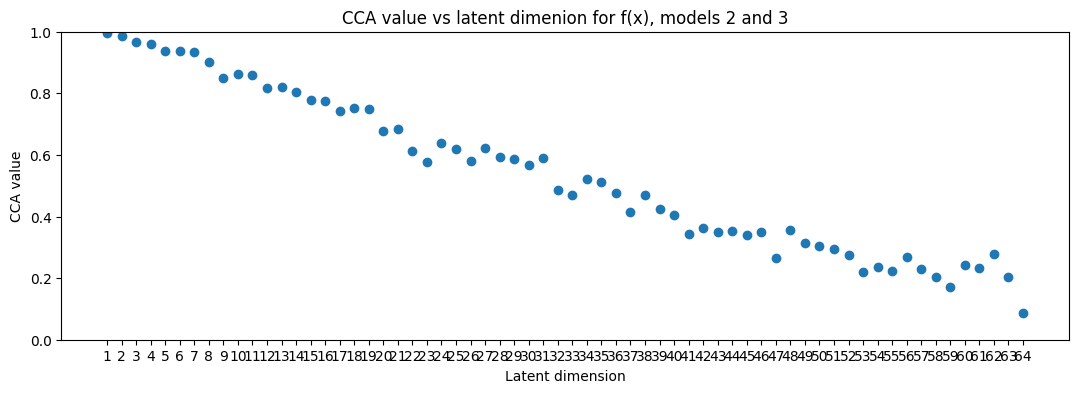

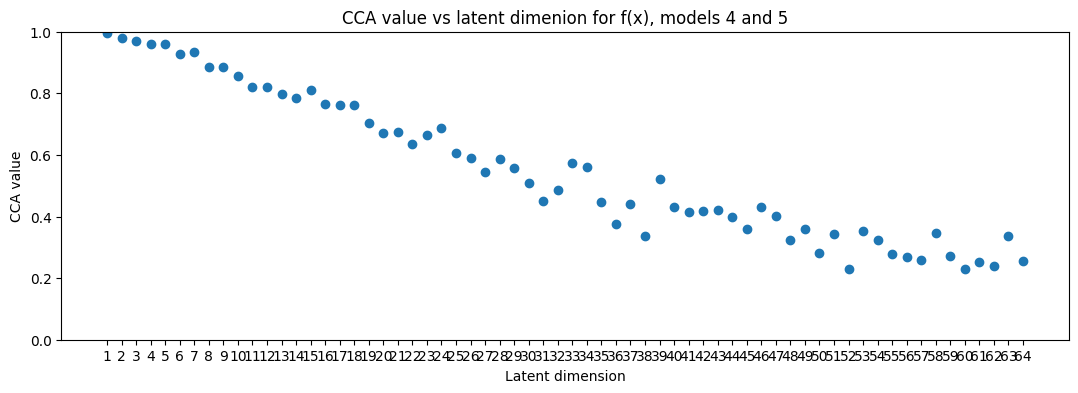

In [9]:
# plot different pairwise comparisons for f(x)
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,1], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,2], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,3], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,4], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[1,2], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[3,4], encoder_type='f(x)')

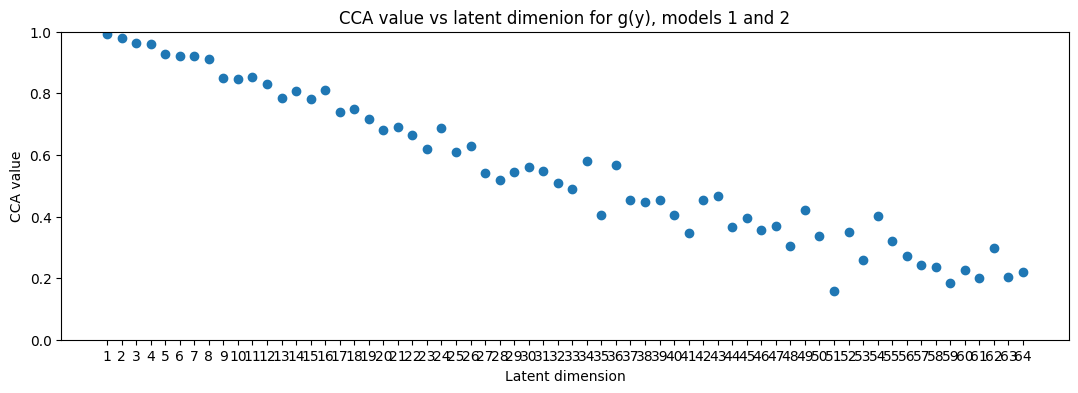

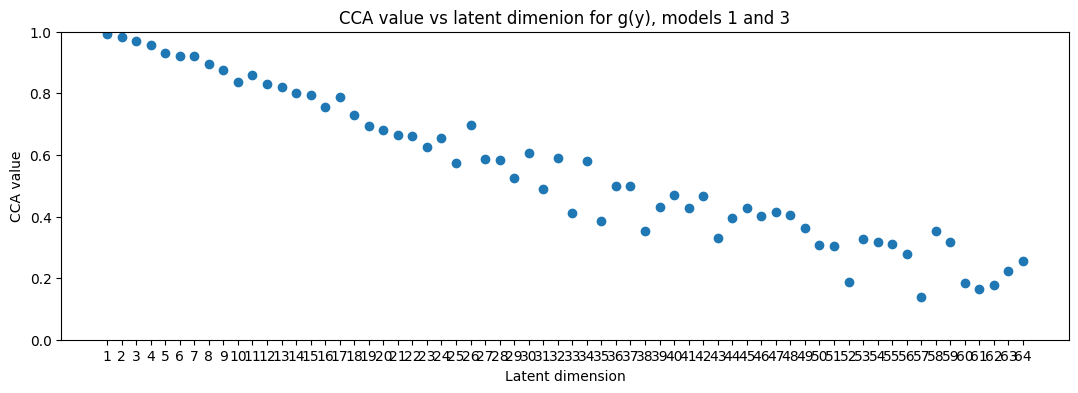

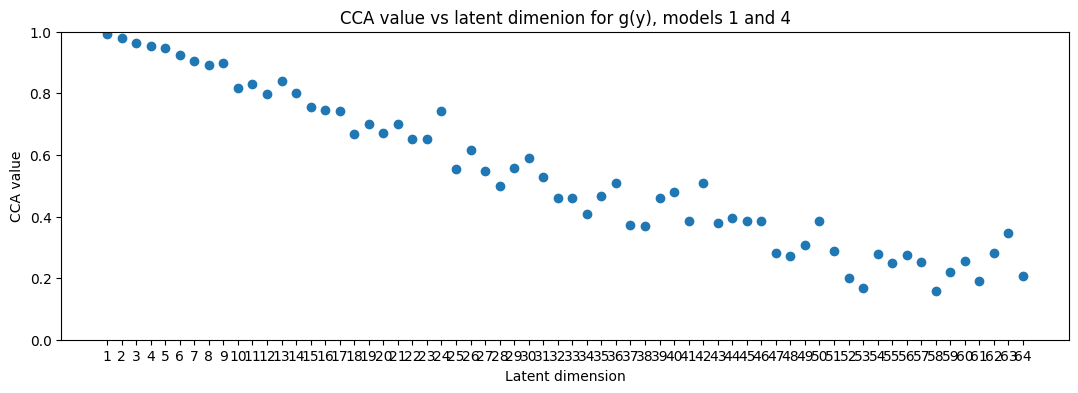

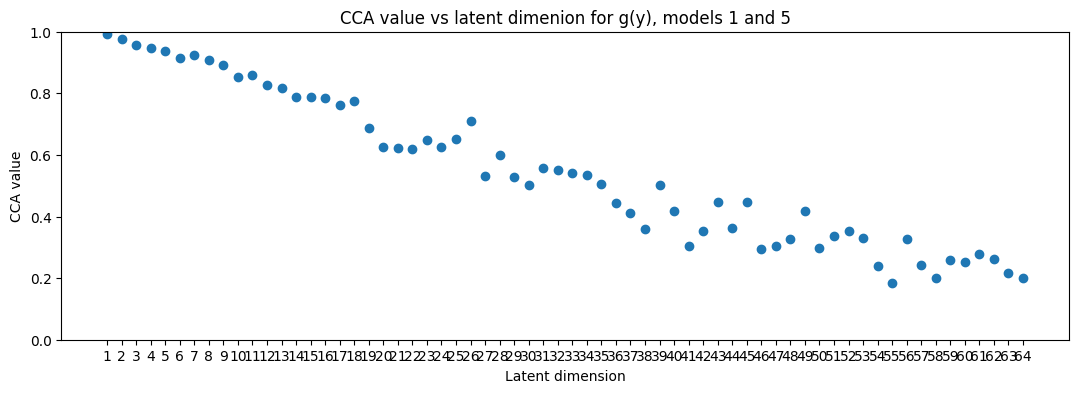

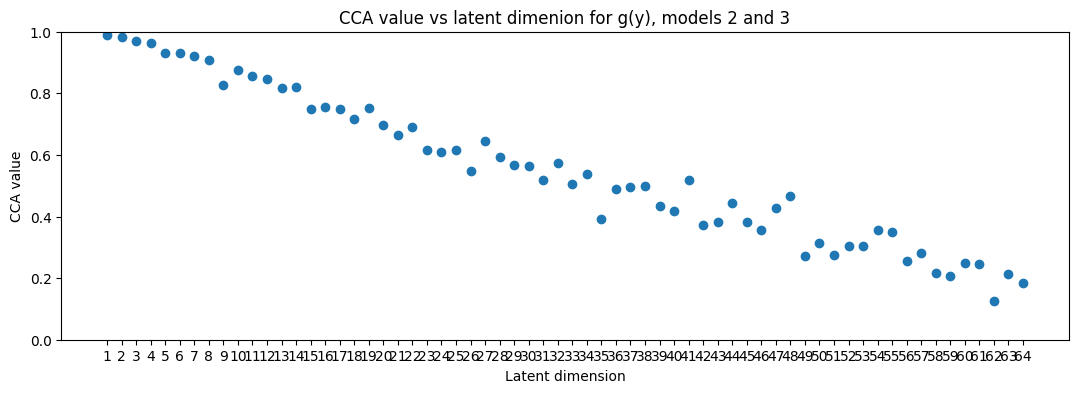

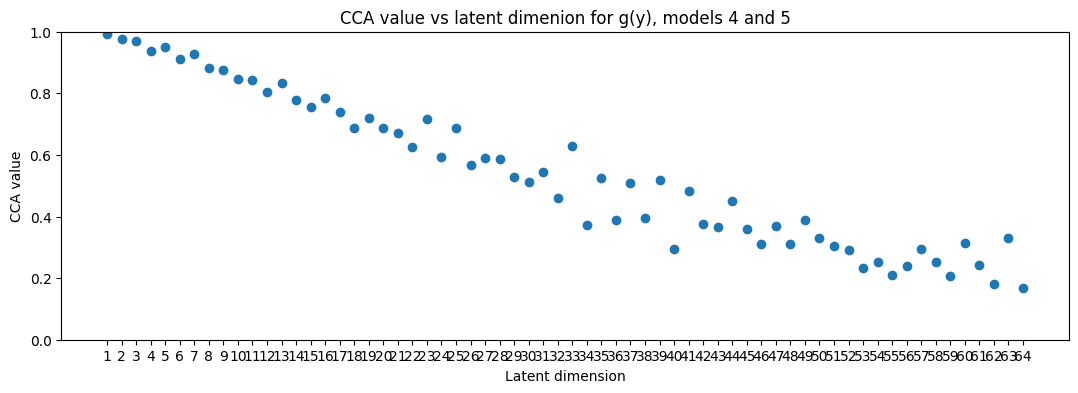

In [10]:
# plot different pairwise comparisons for g(y)
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[0,1], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[0,2], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[0,3], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[0,4], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[1,2], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[3,4], encoder_type='g(y)')

(64,) (64,)


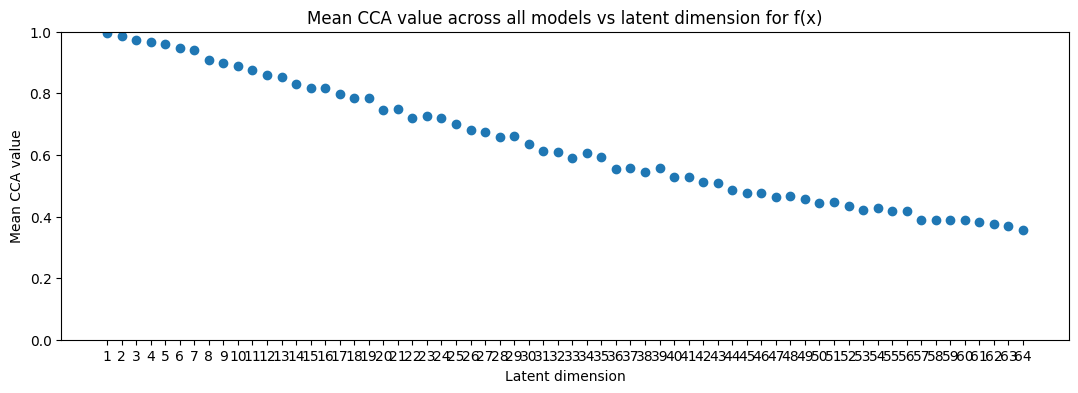

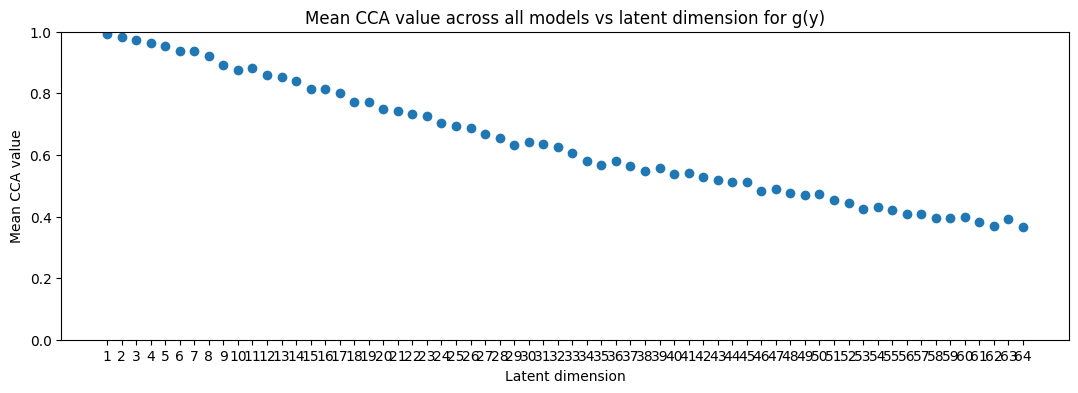

In [12]:
# calculate the mean CCA value across all models and plot it against the latents 
mean_cca_x = CCA_multi_x.calculate_mean_cca(mcorrs_x)
mean_cca_y = CCA_multi_y.calculate_mean_cca(mcorrs_y)

print(mean_cca_x.shape, mean_cca_y.shape)

CCA_multi_x.plot_cca_v_latent(mean_cca_x, encoder_type='f(x)', mean=True)
CCA_multi_y.plot_cca_v_latent(mean_cca_y, encoder_type='g(y)', mean=True)

### Visualize the latents 

In [14]:
# fig, axs = plt.subplots(len(encoder_x_list), 2, figsize = (12, 4 * len(encoder_x_list)))

# for i, row_axs in enumerate(axs):
#     encoder_x = encoder_x_list[i]
#     encoder_y = encoder_y_list[i]
#     with torch.no_grad():
#         zx = encoder_x(torch.tensor(x).to(torch.float32))
#         zy = encoder_y(torch.tensor(y).to(torch.float32))
#     ax = row_axs[0]
    
#     ax.scatter(*zx.cpu().T)
#     ax.set(title = "Encoding features", xlabel = r"$\vec{f}(\mathbf{x})$ 1st dim", ylabel = r"$\vec{f}(\mathbf{x})$ 2nd dim")
#     ax = row_axs[1]
#     ax.scatter(*zy.cpu().T, vmin  = 0, vmax = 1, cmap = "bwr")
#     ax.set(title = "Encoding labels", xlabel = r"$\vec{g}(\mathbf{y})$ 1st dim", ylabel = r"$\vec{g}(\mathbf{y})$ 2nd dim")


# plt.subplots_adjust(wspace = 0.5, hspace = 0.5)